In [1]:
#ml model implementation steps

#1.problem analysis
#2.data collection
#3.cleaning and preprocessing the data---pandas , numpy
#4.visualisation of data--matplotlib,seaborn
#5.lebeling pf the data----(x,input data,features,independent values)(y,output data,target,dependent values)
#6.split the data for training and testing----(training---80%)(testing--20%)
#7.model buildig---algorithm selection
#8.Train the model---(using x_train and y_train)
#9.Testing the model----(x_test--->predicted value)
#10. model evaluation---(predicted value---y_test)
#11.model deployment

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
df=pd.read_csv("healthcare-dataset-stroke-data.csv")
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [4]:
#data inspection -- to understand the data
print(df.shape)

(5110, 12)


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB
None


In [6]:
print(df.describe())

                 id          age  hypertension  heart_disease  \
count   5110.000000  5110.000000   5110.000000    5110.000000   
mean   36517.829354    43.226614      0.097456       0.054012   
std    21161.721625    22.612647      0.296607       0.226063   
min       67.000000     0.080000      0.000000       0.000000   
25%    17741.250000    25.000000      0.000000       0.000000   
50%    36932.000000    45.000000      0.000000       0.000000   
75%    54682.000000    61.000000      0.000000       0.000000   
max    72940.000000    82.000000      1.000000       1.000000   

       avg_glucose_level          bmi       stroke  
count        5110.000000  4909.000000  5110.000000  
mean          106.147677    28.893237     0.048728  
std            45.283560     7.854067     0.215320  
min            55.120000    10.300000     0.000000  
25%            77.245000    23.500000     0.000000  
50%            91.885000    28.100000     0.000000  
75%           114.090000    33.100000     0

In [7]:
#Checking for null values
print(df.isnull().sum())

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


In [8]:
df['bmi'].fillna(df['bmi'].mean(),inplace=True)
df

C:\Users\blesi\AppData\Local\Temp\ipykernel_25740\2052970504.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bmi'].fillna(df['bmi'].mean(),inplace=True)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.600000,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.893237,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.500000,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.400000,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.000000,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,28.893237,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.000000,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.600000,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.600000,formerly smoked,0


In [9]:
print(df.isnull().sum())

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64


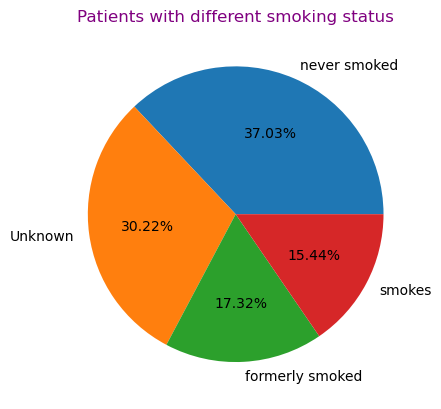

In [10]:
#visualizations

#Patients with different smoking status
smoke=df['smoking_status'].value_counts()
print(smoke)
x=smoke.index
y=smoke.values
plt.pie(y,labels=x,autopct='%1.2f%%')
plt.title("Patients with different smoking status",color='purple')
plt.show()

gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64
Index(['Female', 'Male', 'Other'], dtype='object', name='gender')


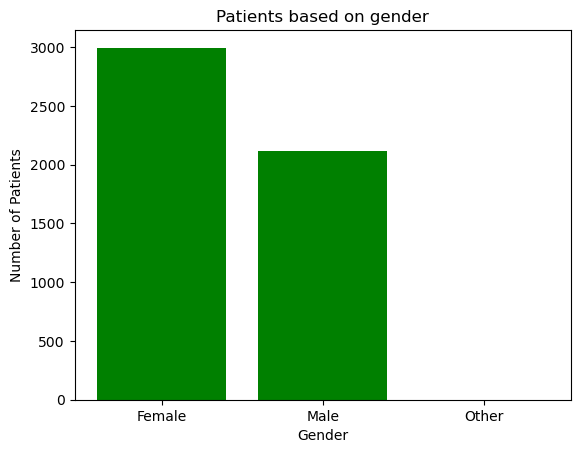

In [11]:
#Patients based on gender
a=df['gender'].value_counts()
print(a)
x=a.index
print(x)
y=a.values
plt.bar(x,y,color='g')
plt.title("Patients based on gender")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")
plt.show()

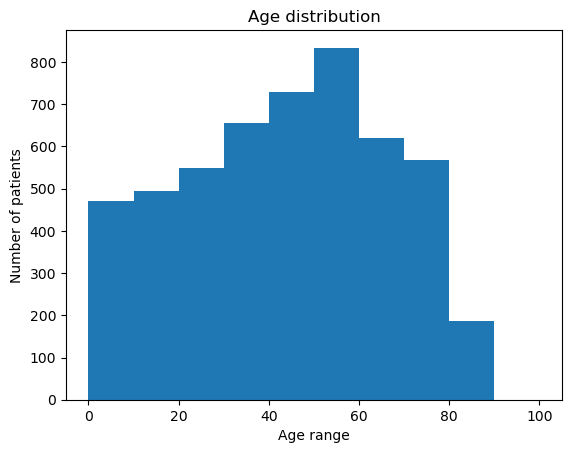

In [12]:
#Age distribution

x=df['age']
k=[0,10,20,30,40,50,60,70,80,90,100]
plt.hist(x,bins=k)
plt.title("Age distribution")
plt.xlabel("Age range")
plt.ylabel("Number of patients")
plt.show()

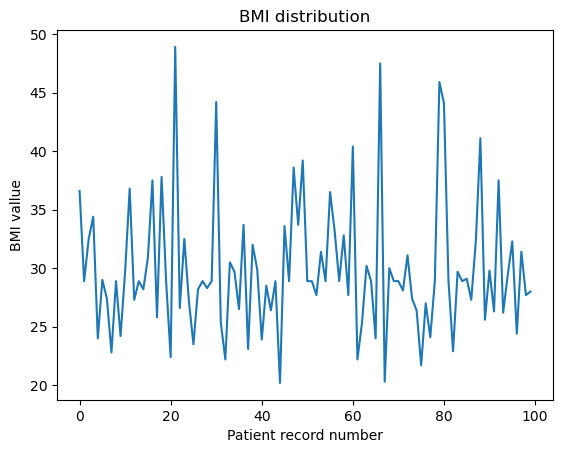

In [13]:
#BMI distribution
a=df.iloc[:100]
b=a['bmi']
plt.plot(b)
plt.title("BMI distribution")
plt.xlabel("Patient record number")
plt.ylabel("BMI vallue")
plt.show()

In [14]:
#Removing unecessary columns
df.drop(['id','ever_married','work_type'],axis=1,inplace=True)
df

,gender,age,hypertension,heart_disease,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Urban,228.69,36.600000,formerly smoked,1
1,Female,61.0,0,0,Rural,202.21,28.893237,never smoked,1
2,Male,80.0,0,1,Rural,105.92,32.500000,never smoked,1
3,Female,49.0,0,0,Urban,171.23,34.400000,smokes,1
4,Female,79.0,1,0,Rural,174.12,24.000000,never smoked,1
...,...,...,...,...,...,...,...,...,...
5105,Female,80.0,1,0,Urban,83.75,28.893237,never smoked,0
5106,Female,81.0,0,0,Urban,125.20,40.000000,never smoked,0
5107,Female,35.0,0,0,Rural,82.99,30.600000,never smoked,0
5108,Male,51.0,0,0,Rural,166.29,25.600000,formerly smoked,0


In [15]:
#Encoding
#gender--mapping
df['gender'].unique()

array(['Male', 'Female', 'Other'], dtype=object)

In [16]:
df['gender']=df['gender'].map({'Female':0,'Male':1,'Other':2})
df

,gender,age,hypertension,heart_disease,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,67.0,0,1,Urban,228.69,36.600000,formerly smoked,1
1,0,61.0,0,0,Rural,202.21,28.893237,never smoked,1
2,1,80.0,0,1,Rural,105.92,32.500000,never smoked,1
3,0,49.0,0,0,Urban,171.23,34.400000,smokes,1
4,0,79.0,1,0,Rural,174.12,24.000000,never smoked,1
...,...,...,...,...,...,...,...,...,...
5105,0,80.0,1,0,Urban,83.75,28.893237,never smoked,0
5106,0,81.0,0,0,Urban,125.20,40.000000,never smoked,0
5107,0,35.0,0,0,Rural,82.99,30.600000,never smoked,0
5108,1,51.0,0,0,Rural,166.29,25.600000,formerly smoked,0


In [17]:
#residence_type---dummy encoding
df=pd.get_dummies(df,columns=['Residence_type'],dtype='int')
df

,gender,age,hypertension,heart_disease,avg_glucose_level,bmi,smoking_status,stroke,Residence_type_Rural,Residence_type_Urban
0,1,67.0,0,1,228.69,36.600000,formerly smoked,1,0,1
1,0,61.0,0,0,202.21,28.893237,never smoked,1,1,0
2,1,80.0,0,1,105.92,32.500000,never smoked,1,1,0
3,0,49.0,0,0,171.23,34.400000,smokes,1,0,1
4,0,79.0,1,0,174.12,24.000000,never smoked,1,1,0
...,...,...,...,...,...,...,...,...,...,...
5105,0,80.0,1,0,83.75,28.893237,never smoked,0,0,1
5106,0,81.0,0,0,125.20,40.000000,never smoked,0,0,1
5107,0,35.0,0,0,82.99,30.600000,never smoked,0,1,0
5108,1,51.0,0,0,166.29,25.600000,formerly smoked,0,1,0


In [18]:
#smoking_status--dummy encoding
df=pd.get_dummies(df,columns=['smoking_status'],dtype='int')
df

,gender,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,Residence_type_Rural,Residence_type_Urban,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,1,67.0,0,1,228.69,36.600000,1,0,1,0,1,0,0
1,0,61.0,0,0,202.21,28.893237,1,1,0,0,0,1,0
2,1,80.0,0,1,105.92,32.500000,1,1,0,0,0,1,0
3,0,49.0,0,0,171.23,34.400000,1,0,1,0,0,0,1
4,0,79.0,1,0,174.12,24.000000,1,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5105,0,80.0,1,0,83.75,28.893237,0,0,1,0,0,1,0
5106,0,81.0,0,0,125.20,40.000000,0,0,1,0,0,1,0
5107,0,35.0,0,0,82.99,30.600000,0,1,0,0,0,1,0
5108,1,51.0,0,0,166.29,25.600000,0,1,0,0,1,0,0


In [19]:
df.shape

(5110, 13)

In [20]:
df.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'avg_glucose_level',
       'bmi', 'stroke', 'Residence_type_Rural', 'Residence_type_Urban',
       'smoking_status_Unknown', 'smoking_status_formerly smoked',
       'smoking_status_never smoked', 'smoking_status_smokes'],
      dtype='object')

In [21]:
#Data labeling
x=df.drop('stroke',axis=1)
y=df['stroke']

In [22]:
print(x.shape)
print(y.shape)

(5110, 12)
(5110,)


In [23]:
#splitting the data for taining and testing
#x_train(80% x),x_test(20% x), y_train(80% y),y_test(20% y)

In [24]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42) #random_state=splitting values will be same howmuch ever times we run the cell
#x_train-input data ,y_train-output data

In [25]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(4088, 12)
(1022, 12)
(4088,)
(1022,)


In [26]:
#Algorithms--classification
#Logistic regression
#Decision Tree
#Random forest
#Support Vector Machine
#Naive Bayes

In [27]:
#Logistic Regression
#1.import algorithm
from sklearn.linear_model import LogisticRegression
#2.object for class
#model
lr=LogisticRegression()

In [28]:
#Model training
lr.fit(x_train,y_train)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [29]:
#Model testing---x_test data
result=lr.predict(x_test)
print(result)

[0 0 0 ... 0 0 0]


In [30]:
#model evaluation
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

score=accuracy_score(y_test,result)
print("Accuracy Score for LR Model:",score)

Accuracy Score for LR Model: 0.9393346379647749


### Day 30

In [31]:
#classification report
report=classification_report(y_test,result)
print("Classification Report:\n")
print(report)

#precision--in total predictions, how many prediction are correct
#recall--the ability to do correct predictions
#f1-score--harmonic mean of precision and recall
#support--data supporting for each class
#accuracy--overall accuracy of model
#macro avg--average of each class result--(ex--precision--(0.94+0.00)/2=0.47)
#weighted avg--avg of each class result along with support--(ex--precision(0.94*960+0.00*62)/1022=0.88)

Classification Report:

              precision    recall  f1-score   support

           0       0.94      1.00      0.97       960
           1       0.00      0.00      0.00        62

    accuracy                           0.94      1022
   macro avg       0.47      0.50      0.48      1022
weighted avg       0.88      0.94      0.91      1022



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[[960   0]
 [ 62   0]]


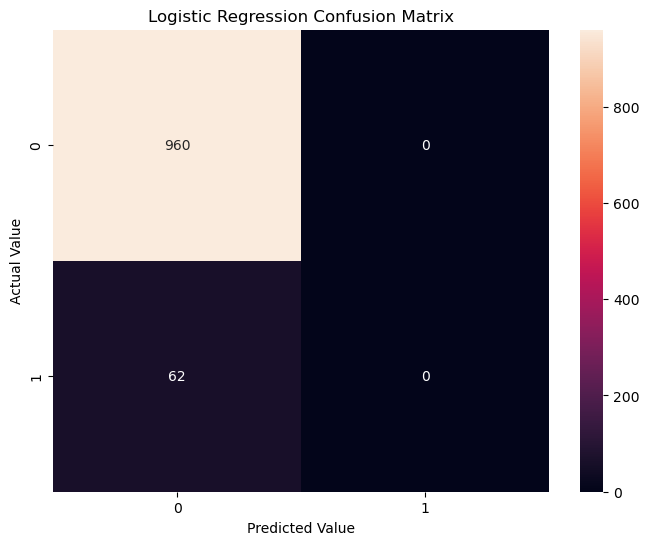

In [32]:
#confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm=confusion_matrix(y_test,result)
print(cm)

plt.figure(figsize=(8,6),dpi=100)
plt.title("Logistic Regression Confusion Matrix")
sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel("Predicted Value")
plt.ylabel("Actual Value")
plt.show()

In [ ]:
# if pos 1 neg 0
#[True Negative] acutally 0 predicted 0
#[True Positive] acutally 1 predicted 1
#[False pos] acutally 1 predicted 0
#[False neg] acutally 0 predicted 1


# predicted:Negative,Predicted:positive
#Actual:Negative,TN (corrrect),FP (Type I Error)
#Actual:Positive,FN(Type II Error), TP (Correct)

In [33]:
#Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier
#model building
dt=DecisionTreeClassifier()
#Model training
dt.fit(x_train,y_train)
#Model testing---x_test data
result_dt=dt.predict(x_test)
print(result_dt)

[0 0 0 ... 0 0 0]


In [34]:
#model evaluation
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

score_dt=accuracy_score(y_test,result_dt)
print("Accuracy Score for DT Model:",score_dt)

Accuracy Score for DT Model: 0.9119373776908023


In [35]:
#classification report
report_dt=classification_report(y_test,result_dt)
print("Classification Report:\n")
print(report_dt)


Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.96      0.95       960
           1       0.23      0.19      0.21        62

    accuracy                           0.91      1022
   macro avg       0.59      0.58      0.58      1022
weighted avg       0.90      0.91      0.91      1022



[[920  40]
 [ 50  12]]


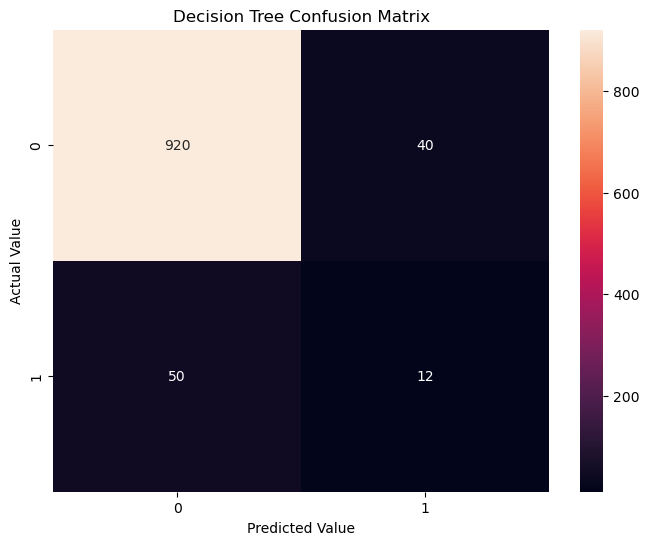

In [37]:
#confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_dt=confusion_matrix(y_test,result_dt)
print(cm_dt)

plt.figure(figsize=(8,6),dpi=100)
plt.title("Decision Tree Confusion Matrix")
sns.heatmap(cm_dt,annot=True,fmt='d')
plt.xlabel("Predicted Value")
plt.ylabel("Actual Value")
plt.show()

In [38]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier

#model building
rf=RandomForestClassifier()
#Model Training
rf.fit(x_train,y_train)
#Model Testing
result_rf=rf.predict(x_test)
print(result_rf)

[0 0 0 ... 0 0 0]


Accuracy Score for RF Model: 0.9383561643835616
Classification Report:

              precision    recall  f1-score   support

           0       0.94      1.00      0.97       960
           1       0.33      0.02      0.03        62

    accuracy                           0.94      1022
   macro avg       0.64      0.51      0.50      1022
weighted avg       0.90      0.94      0.91      1022

[[958   2]
 [ 61   1]]


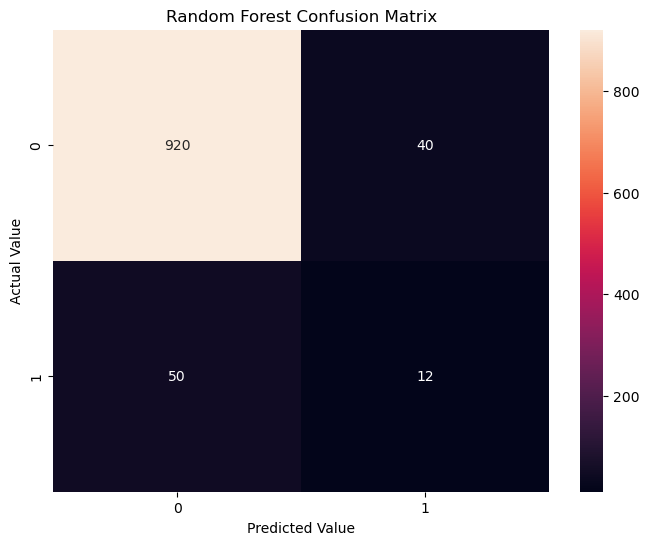

In [39]:
#model evaluation
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

score_rf=accuracy_score(y_test,result_rf)
print("Accuracy Score for RF Model:",score_rf)

#classification report
report_rf=classification_report(y_test,result_rf)
print("Classification Report:\n")
print(report_rf)

#confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_rf=confusion_matrix(y_test,result_rf)
print(cm_rf)

plt.figure(figsize=(8,6),dpi=100)
plt.title("Random Forest Confusion Matrix")
sns.heatmap(cm_dt,annot=True,fmt='d')
plt.xlabel("Predicted Value")
plt.ylabel("Actual Value")
plt.show()

In [40]:
#Support Vector Machine
from sklearn.svm import SVC
#model building
svc=SVC()
#Model Training
svc.fit(x_train,y_train)
#Model Testing
result_svc=rf.predict(x_test)
print(result_svc)

[0 0 0 ... 0 0 0]


Accuracy Score for RF Model: 0.9383561643835616
Classification Report:

              precision    recall  f1-score   support

           0       0.94      1.00      0.97       960
           1       0.33      0.02      0.03        62

    accuracy                           0.94      1022
   macro avg       0.64      0.51      0.50      1022
weighted avg       0.90      0.94      0.91      1022

[[958   2]
 [ 61   1]]


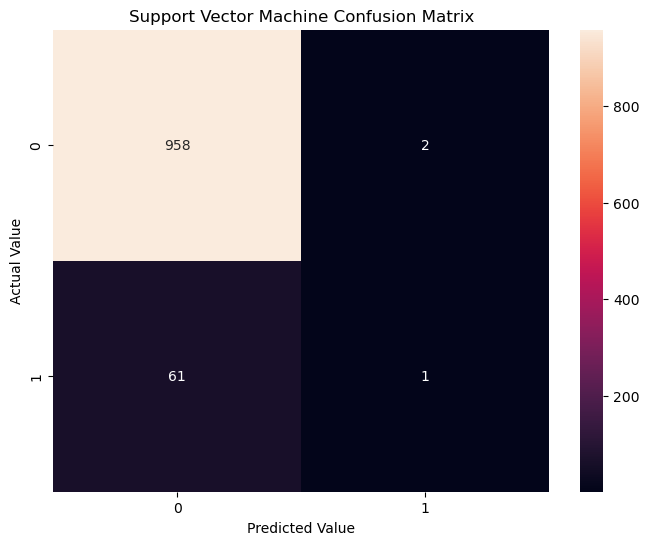

In [41]:
#model evaluation
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

score_svc=accuracy_score(y_test,result_svc)
print("Accuracy Score for RF Model:",score_svc)

#classification report
report_svc=classification_report(y_test,result_svc)
print("Classification Report:\n")
print(report_svc)

#confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_svc=confusion_matrix(y_test,result_svc)
print(cm_svc)

plt.figure(figsize=(8,6),dpi=100)
plt.title("Support Vector Machine Confusion Matrix")
sns.heatmap(cm_svc,annot=True,fmt='d')
plt.xlabel("Predicted Value")
plt.ylabel("Actual Value")
plt.show()

In [42]:
print(y.unique())
print(y.value_counts())

[1 0]
stroke
0    4861
1     249
Name: count, dtype: int64


In [43]:
print(y_train.unique())
print(y_train.value_counts())
#Balancing Required for data to increase accuracy

[0 1]
stroke
0    3901
1     187
Name: count, dtype: int64


In [44]:
#Overfitting--performs good for training data, and bad performance for test data
#Underfitting--Bad performance in both Training and Testing data(When you have less Data)

#Go with data Ballancing

In [45]:
#Oversampling Method of Balancing
from imblearn.over_sampling import SMOTE #Used to create random sample based on the data for balancing the dataset
smt=SMOTE()
x_train_sampled,y_train_sampled=smt.fit_resample(x_train,y_train) #Only applied for training

In [46]:
print(x_train_sampled.shape)
print(y_train_sampled.shape)

(7802, 12)
(7802,)


In [47]:
print(y_train_sampled.unique())
print(y_train_sampled.value_counts())

[0 1]
stroke
0    3901
1    3901
Name: count, dtype: int64


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[0 0 0 ... 0 0 0]
Accuracy Score for LR Model: 0.9197651663405088
Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.97      0.96       960
           1       0.22      0.13      0.16        62

    accuracy                           0.92      1022
   macro avg       0.58      0.55      0.56      1022
weighted avg       0.90      0.92      0.91      1022

[[932  28]
 [ 54   8]]


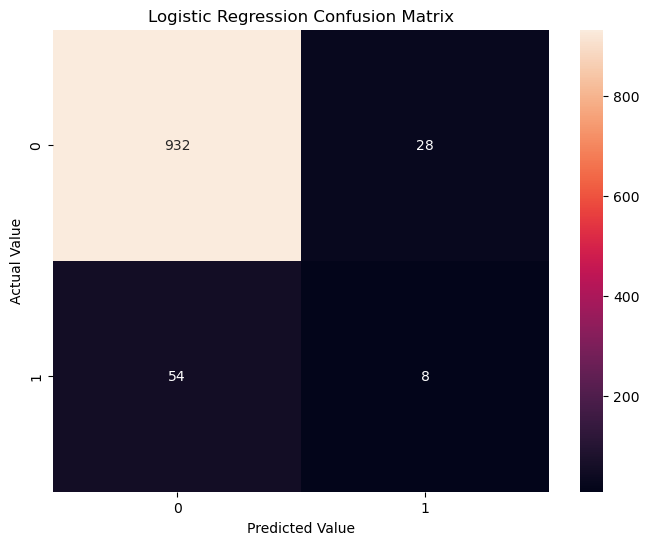

In [48]:
#Logistic Regression
#1.import algorithm
from sklearn.linear_model import LogisticRegression
#model
lr=LogisticRegression()
#Model training
lr.fit(x_train_sampled,y_train_sampled)
#Model testing---x_test data
result=lr.predict(x_test)
print(result)
#model evaluation
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

score=accuracy_score(y_test,result)
print("Accuracy Score for LR Model:",score)
#classification report
report=classification_report(y_test,result)
print("Classification Report:\n")
print(report)
#confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm=confusion_matrix(y_test,result)
print(cm)

plt.figure(figsize=(8,6),dpi=100)
plt.title("Logistic Regression Confusion Matrix")
sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel("Predicted Value")
plt.ylabel("Actual Value")
plt.show()

[0 0 0 ... 1 0 0]
Accuracy Score for DT Model: 0.8992172211350293
Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.94      0.95       960
           1       0.20      0.23      0.21        62

    accuracy                           0.90      1022
   macro avg       0.58      0.58      0.58      1022
weighted avg       0.90      0.90      0.90      1022

[[905  55]
 [ 48  14]]


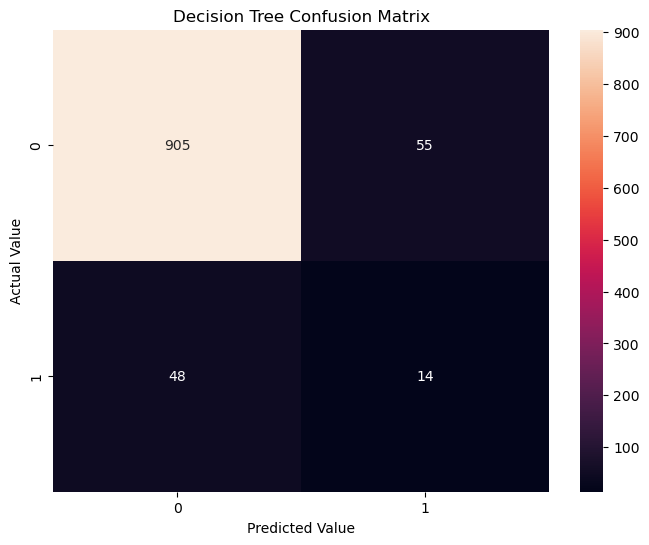

In [49]:
#Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier
#model building
dt=DecisionTreeClassifier()
#Model training
dt.fit(x_train_sampled,y_train_sampled)
#Model testing---x_test data
result_dt=dt.predict(x_test)
print(result_dt)
#model evaluation
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

score_dt=accuracy_score(y_test,result_dt)
print("Accuracy Score for DT Model:",score_dt)
#classification report
report_dt=classification_report(y_test,result_dt)
print("Classification Report:\n")
print(report_dt)
#confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_dt=confusion_matrix(y_test,result_dt)
print(cm_dt)

plt.figure(figsize=(8,6),dpi=100)
plt.title("Decision Tree Confusion Matrix")
sns.heatmap(cm_dt,annot=True,fmt='d')
plt.xlabel("Predicted Value")
plt.ylabel("Actual Value")
plt.show()

[0 0 0 ... 0 0 0]
Accuracy Score for RF Model: 0.9344422700587084
Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.99      0.97       960
           1       0.33      0.08      0.13        62

    accuracy                           0.93      1022
   macro avg       0.64      0.54      0.55      1022
weighted avg       0.91      0.93      0.92      1022

[[950  10]
 [ 57   5]]


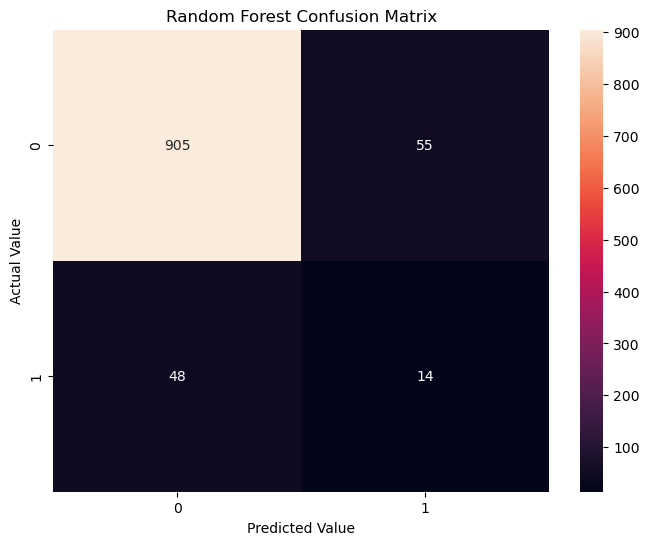

In [50]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier

#model building
rf=RandomForestClassifier()
#Model Training
rf.fit(x_train_sampled,y_train_sampled)
#Model Testing
result_rf=rf.predict(x_test)
print(result_rf)
#model evaluation
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

score_rf=accuracy_score(y_test,result_rf)
print("Accuracy Score for RF Model:",score_rf)

#classification report
report_rf=classification_report(y_test,result_rf)
print("Classification Report:\n")
print(report_rf)

#confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_rf=confusion_matrix(y_test,result_rf)
print(cm_rf)

plt.figure(figsize=(8,6),dpi=100)
plt.title("Random Forest Confusion Matrix")
sns.heatmap(cm_dt,annot=True,fmt='d')
plt.xlabel("Predicted Value")
plt.ylabel("Actual Value")
plt.show()

[0 0 0 ... 0 0 0]
Accuracy Score for RF Model: 0.9344422700587084
Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.99      0.97       960
           1       0.33      0.08      0.13        62

    accuracy                           0.93      1022
   macro avg       0.64      0.54      0.55      1022
weighted avg       0.91      0.93      0.92      1022

[[950  10]
 [ 57   5]]


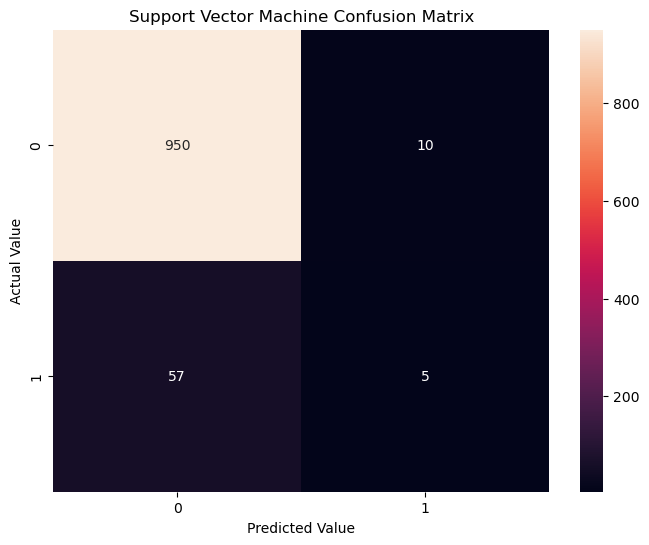

In [51]:
#Support Vector Machine
from sklearn.svm import SVC
#model building
svc=SVC()
#Model Training
svc.fit(x_train_sampled,y_train_sampled)
#Model Testing
result_svc=rf.predict(x_test)
print(result_svc)
#model evaluation
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

score_svc=accuracy_score(y_test,result_svc)
print("Accuracy Score for RF Model:",score_svc)

#classification report
report_svc=classification_report(y_test,result_svc)
print("Classification Report:\n")
print(report_svc)

#confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_svc=confusion_matrix(y_test,result_svc)
print(cm_svc)

plt.figure(figsize=(8,6),dpi=100)
plt.title("Support Vector Machine Confusion Matrix")
sns.heatmap(cm_svc,annot=True,fmt='d')
plt.xlabel("Predicted Value")
plt.ylabel("Actual Value")
plt.show()